# Alerts demo (synthetic data)

This notebook showcases the functionality of alerts 1–10 using **synthetically generated** input data.
Data is generated by `src/data_pregen_utils_alerts.py`, the alerts themselves are implemented in `src/alerts.py`. Various utils are stored in `src/util_alerts.py`

The goals of this demo are:
- to show that each of the alerts can be triggered by input data
- showcase the speed & efficiency of alert calculation
- visually demonstrate each of the alerts using the data

## 0.1) Necessary imports (Hide)

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from data_pregen_utils_alerts import generate_demo_inputs
from alerts import run_alerts
from IPython.display import display
import matplotlib.dates as mdates



## 0.2) Plotting helpers (Hide)

In [2]:
def _safe_dt(x):
    """
    Convert to datetime and normalize to day
    """
    return pd.to_datetime(x, errors="coerce").dt.normalize()

def _first_present(df, cols, default=None):
    """
    Return first column from cols that exists in df
    """
    for c in cols:
        if c in df.columns:
            return c
    return default

def plot_scatter_threshold(df, xcol, ycol, thr, mode, title, xlabel, ylabel, max_points=1200):
    """
    Scatterplot with red threshold lines and red squares for alert points
    """
    if df is None or df.empty:
        print("the dataframe is empty")
        return

    d = df[[xcol, ycol]].copy()
    d[xcol] = pd.to_numeric(d[xcol], errors="coerce")
    d[ycol] = pd.to_numeric(d[ycol], errors="coerce")
    d = d.dropna()
    if d.empty:
        print("there are no points")
        return

    if len(d) > max_points:
        d = d.sample(max_points, random_state=7)

    x = d[xcol].to_numpy()
    y = d[ycol].to_numpy()

    xmin, xmax = float(np.nanmin(x)), float(np.nanmax(x))
    ymin, ymax = float(np.nanmin(y)), float(np.nanmax(y))
    pad_x = (xmax - xmin) * 0.05 if xmax > xmin else 1.0
    pad_y = (ymax - ymin) * 0.05 if ymax > ymin else 1.0

    xs = np.linspace(xmin - pad_x, xmax + pad_x, 200)
    thr = float(thr) if thr is not None else 1.0
    if thr <= 0:
        thr = 1.0

    plt.figure()
    plt.scatter(x, y, alpha=0.35)

    if mode in ("high", "both"):
        plt.plot(xs, thr * xs, color="red", linestyle="--", linewidth=2, label=f"y = {thr}·x")
        bad = y > thr * x
        plt.scatter(x[bad], y[bad], marker="s", facecolors="none", edgecolors="red", linewidths=2, label="alert points")

    if mode in ("low", "both"):
        plt.plot(xs, xs / thr, color="red", linestyle="--", linewidth=2, label=f"y = x/{thr}")
        bad = y < x / thr
        plt.scatter(x[bad], y[bad], marker="s", facecolors="none", edgecolors="red", linewidths=2, label="alert points")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_ts_one(df, date_col, val_col, alert_mask=None, title="", ylabel=""):
    """
    Time series plot with red squares on alert points
    """
    if df is None or df.empty:
        print("the dataframe is empty")
        return

    d = df[[date_col, val_col]].copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d[val_col] = pd.to_numeric(d[val_col], errors="coerce")
    d = d.dropna(subset=[date_col]).sort_values(date_col)

    if d.empty:
        print("dates or values are missing")
        return

    plt.figure()
    plt.plot(d[date_col], d[val_col], linewidth=2)

    if alert_mask is not None:
        m = alert_mask.reindex(d.index).fillna(False).to_numpy()
        plt.scatter(d.loc[m, date_col], d.loc[m, val_col], marker="s",
                    facecolors="none", edgecolors="red", linewidths=2, s=80, label="alert points")

    plt.title(title)
    plt.xlabel(date_col)
    plt.ylabel(ylabel or val_col)
    plt.grid(True, alpha=0.25)
    loc = mdates.AutoDateLocator()
    plt.gca().xaxis.set_major_locator(loc)
    plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_ts_two(df, date_col, y1_col, y2_col, alert_mask=None, title="", y1_label=None, y2_label=None):
    """
    Two time series plots (context) + red squares on alert points
    """
    if df is None or df.empty:
        print("the dataframe is empty")
        return

    d = df[[date_col, y1_col, y2_col]].copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d[y1_col] = pd.to_numeric(d[y1_col], errors="coerce")
    d[y2_col] = pd.to_numeric(d[y2_col], errors="coerce")
    d = d.dropna(subset=[date_col]).sort_values(date_col)
    if d.empty:
        print("no dates")
        return

    plt.figure()
    plt.plot(d[date_col], d[y1_col], linewidth=2, label=y1_label or y1_col)
    plt.plot(d[date_col], d[y2_col], linewidth=2, label=y2_label or y2_col)

    if alert_mask is not None:
        m = alert_mask.reindex(d.index).fillna(False).to_numpy()
        plt.scatter(d.loc[m, date_col], d.loc[m, y1_col], marker="s",
                    facecolors="none", edgecolors="red", linewidths=2, s=80, label="alert points")

    plt.title(title)
    plt.xlabel(date_col)
    plt.grid(True, alpha=0.25)
    loc = mdates.AutoDateLocator()
    plt.gca().xaxis.set_major_locator(loc)
    plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    plt.legend()
    plt.tight_layout()
    plt.show()


## *) Generating input data, calculating alerts

In [3]:
# params
PARAMS = dict(
    n_products=400,
    n_locations=60,
    n_customers=20,
    n_channels=2,
    n_series=2500,     # number of time series keys
    hist_years=3,
    fc_weeks=12,
    seed=7,
)

t0 = time.perf_counter()
tables, prod, loc, cust, dc, alert_params_df, config_params_df, initial_global, tgt_var_cfg = \
    generate_demo_inputs(**PARAMS)
t1 = time.perf_counter()

out = run_alerts(
    tables=tables,
    alert_parameters=alert_params_df,
    prod=prod, loc=loc, cust=cust, dc=dc,
    config_parameters=config_params_df,
    initial_global=initial_global,
    tgt_var_cfg=tgt_var_cfg,
)
t2 = time.perf_counter()

print('data generation (sec):', round(t1 - t0, 3))
print('alerts run (sec):', round(t2 - t1, 3))
print('alerted rows:', len(out))
out.head()

data generation (sec): 0.131
alerts run (sec): 57.076
alerted rows: 5445


,PRODUCT_LVL_ID7,LOCATION_LVL_ID5,CUSTOMER_LVL_ID3,DISTR_CHANNEL_LVL_ID1,PERIOD_DT,STAT_NOM_VAL,STAT_DEN_VAL,ALERT_TYPE,KPI_NM,INPUT_TABLE,...,STAT_DEN_NM,ALERT_THRESHOLD,STAT_NOM,STAT_DEN,ALERT_STAT_VAL,INPUT_COLUMN,INPUT_TABLE_COLUMN,PRODUCT_LVL_ID6,STAT_COUNT,SEGMENT_NAME
0,100,1,3,2,2025-12-16,NaN,1.00000,NAREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,0.0,NaN,1.00000,NaN,NaN,NaN,NaN,NaN,NaN
1,100,1,3,2,2025-12-23,NaN,1.00000,NAREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,0.0,NaN,1.00000,NaN,NaN,NaN,NaN,NaN,NaN
2,180,4,2,2,2025-12-16,0.000000,1.00000,ZEROREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,0.0,0.000000,1.00000,0.000000,NaN,NaN,NaN,NaN,NaN
3,180,4,2,2,2025-12-23,0.000000,1.00000,ZEROREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,0.0,0.000000,1.00000,0.000000,NaN,NaN,NaN,NaN,NaN
4,15,1,1,1,2025-12-16,2736.259934,86.50866,INCRREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Last year demand value,2.0,2736.259934,86.50866,31.629896,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN


## 1) Observe all alerts

How many times was each of the alerts triggered?

ALERT_TYPE
ZEROFLG    2124
DEVWK      1553
NONSEAS    1299
DECRREG     114
INCRREG     111
LOWREG      106
HIGHREG      87
SHRNEW       36
NAREG         6
ZEROREG       6
LOWNEW        3
Name: count, dtype: int64

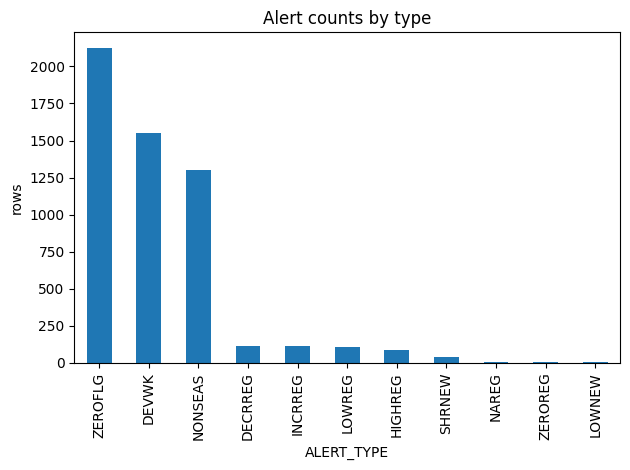

In [4]:
cnt = out['ALERT_TYPE'].value_counts()
display(cnt)

plt.figure()
cnt.plot(kind='bar')
plt.title('Alert counts by type')
plt.xlabel('ALERT_TYPE')
plt.ylabel('rows')
plt.tight_layout()
plt.show()

Which products tend to trigger each of the alerts most often?

In [5]:
if 'PRODUCT_ID' in out.columns:
    g = out.groupby(['ALERT_TYPE','PRODUCT_ID'], dropna=False).size().reset_index(name='cnt')
    top = g.sort_values(['ALERT_TYPE','cnt'], ascending=[True, False]).groupby('ALERT_TYPE').head(10)
    display(top)
else:
    # fallback: if there is no PRODUCT_ID, try to find the next most detailed product lvl
    pcol = _first_present(out, [c for c in out.columns if c.startswith('PRODUCT_LVL_ID')])
    if pcol is None:
        print("there are no PRODUCT_ID / PRODUCT_LVL_ID* - the calculation cannot be completed")
    else:
        g = out.groupby(['ALERT_TYPE', pcol], dropna=False).size().reset_index(name='cnt')
        top = g.sort_values(['ALERT_TYPE','cnt'], ascending=[True, False]).groupby('ALERT_TYPE').head(10)
        display(top)


,ALERT_TYPE,PRODUCT_LVL_ID7,cnt
0,DECRREG,6,36
2,DECRREG,237,36
3,DECRREG,288,36
1,DECRREG,180,6
268,DEVWK,397,46
183,DEVWK,288,43
39,DEVWK,66,40
7,DEVWK,6,37
12,DEVWK,15,36
150,DEVWK,237,36


## 2) Case: Alert 1 (ZEROREG / NAREG)
The idea: for a regular product, there should be a non-zero forecast. The alert is triggered if this is the case

In [6]:
a1 = out[out['ALERT_TYPE'].isin(['ZEROREG','NAREG'])].copy()
a1.head()

,PRODUCT_LVL_ID7,LOCATION_LVL_ID5,CUSTOMER_LVL_ID3,DISTR_CHANNEL_LVL_ID1,PERIOD_DT,STAT_NOM_VAL,STAT_DEN_VAL,ALERT_TYPE,KPI_NM,INPUT_TABLE,...,STAT_DEN_NM,ALERT_THRESHOLD,STAT_NOM,STAT_DEN,ALERT_STAT_VAL,INPUT_COLUMN,INPUT_TABLE_COLUMN,PRODUCT_LVL_ID6,STAT_COUNT,SEGMENT_NAME
0,100,1,3,2,2025-12-16,NaN,1.0,NAREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,100,1,3,2,2025-12-23,NaN,1.0,NAREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,180,4,2,2,2025-12-16,0.0,1.0,ZEROREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN
3,180,4,2,2,2025-12-23,0.0,1.0,ZEROREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN
1552,100,1,3,2,2025-12-16,NaN,1.0,NAREG,sellout.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_SELLOUT,...,na,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN


##### Display

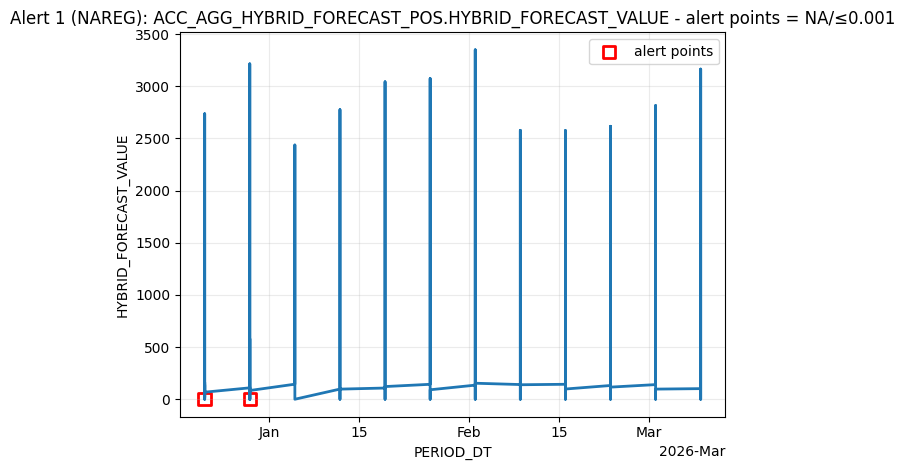

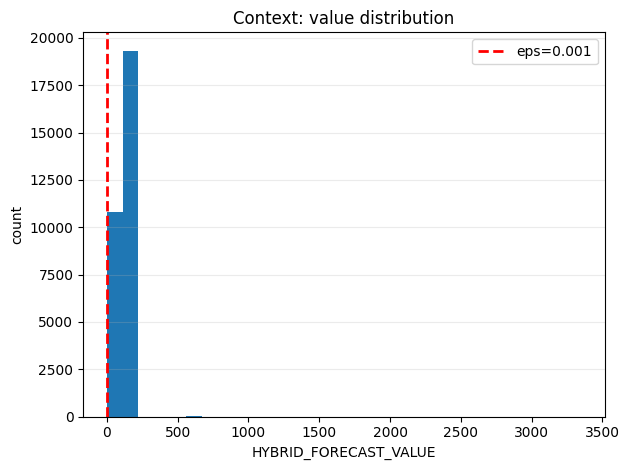

In [7]:
if not a1.empty:
    ex = a1.iloc[0]
    tbl = ex.get('INPUT_TABLE')
    col = ex.get('INPUT_COLUMN')

    src = tables.get(tbl)
    if src is None or src.empty:
        print('no src table', tbl)
    else:
        s = src.copy()

        for c in ['PRODUCT_ID','LOCATION_ID','CUSTOMER_ID','DISTR_CHANNEL_ID']:
            if c in s.columns and c in ex.index and pd.notna(ex[c]):
                s = s[s[c] == ex[c]]

        date_col = 'PERIOD_DT' if 'PERIOD_DT' in s.columns else _first_present(s, ['PERIOD_START_DT'])
        val_col = col if (col in s.columns) else _first_present(
            s, ['HYBRID_FORECAST_VALUE','VF_FORECAST_VALUE','FORECAST_VALUE'], default=s.columns[-1]
        )

        s[date_col] = pd.to_datetime(s[date_col], errors='coerce')
        s[val_col] = pd.to_numeric(s[val_col], errors='coerce')

        eps = 0.001 # the threshold for what we interpret as "almost zero"
        alert_mask = s[val_col].isna() | (s[val_col] <= eps)

        plot_ts_one(
            s,
            date_col=date_col,
            val_col=val_col,
            alert_mask=alert_mask,
            title=f"Alert 1 ({ex['ALERT_TYPE']}): {tbl}.{val_col} - alert points = NA/≤{eps}",
            ylabel=val_col
        )

        v = s[val_col].to_numpy()
        v = v[np.isfinite(v)]
        if len(v):
            plt.figure()
            plt.hist(v, bins=30)
            plt.axvline(eps, color='red', linestyle='--', linewidth=2, label=f'eps={eps}')
            plt.title("Context: value distribution")
            plt.xlabel(val_col)
            plt.ylabel("count")
            plt.grid(True, axis='y', alpha=0.25)
            plt.legend()
            plt.tight_layout()
            plt.show()


Most records did not trigger the alert, but a few did

## 3) Case: Alert 2/3 (INCRREG / DECRREG)
The idea: the forecast deviates from the same period last year by way too large of a value.

In [8]:
a23 = out[out['ALERT_TYPE'].isin(['INCRREG','DECRREG'])].copy()
a23.head()

,PRODUCT_LVL_ID7,LOCATION_LVL_ID5,CUSTOMER_LVL_ID3,DISTR_CHANNEL_LVL_ID1,PERIOD_DT,STAT_NOM_VAL,STAT_DEN_VAL,ALERT_TYPE,KPI_NM,INPUT_TABLE,...,STAT_DEN_NM,ALERT_THRESHOLD,STAT_NOM,STAT_DEN,ALERT_STAT_VAL,INPUT_COLUMN,INPUT_TABLE_COLUMN,PRODUCT_LVL_ID6,STAT_COUNT,SEGMENT_NAME
4,15,1,1,1,2025-12-16,2736.259934,86.508660,INCRREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Last year demand value,2.0,2736.259934,86.508660,31.629896,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
5,15,1,1,1,2025-12-23,3214.687028,102.377351,INCRREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Last year demand value,2.0,3214.687028,102.377351,31.400373,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
6,15,1,1,1,2025-12-30,2436.763867,81.470559,INCRREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Last year demand value,2.0,2436.763867,81.470559,29.909748,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
7,15,1,1,1,2026-01-06,2775.341235,94.488435,INCRREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Last year demand value,2.0,2775.341235,94.488435,29.372285,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
8,15,1,1,1,2026-01-13,3042.808745,105.205282,INCRREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Last year demand value,2.0,3042.808745,105.205282,28.922585,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN


##### Display

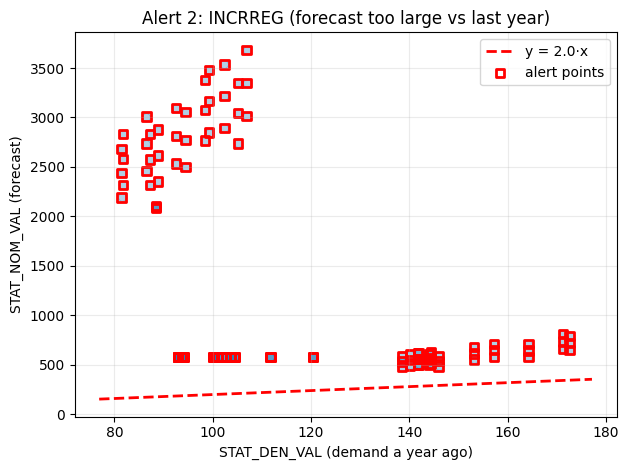

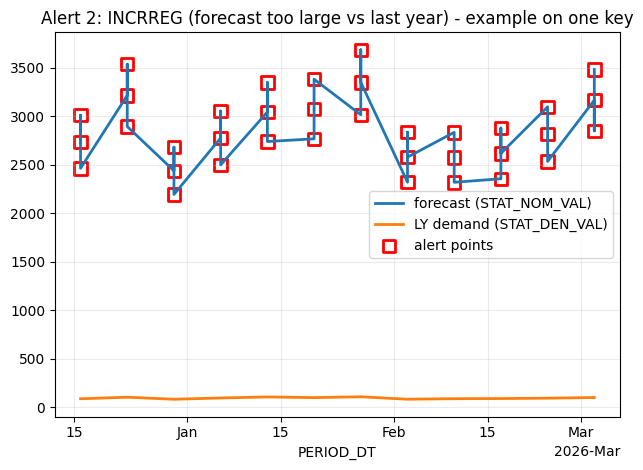

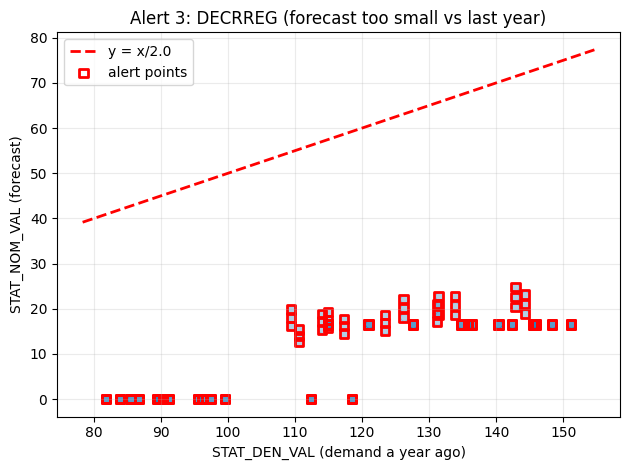

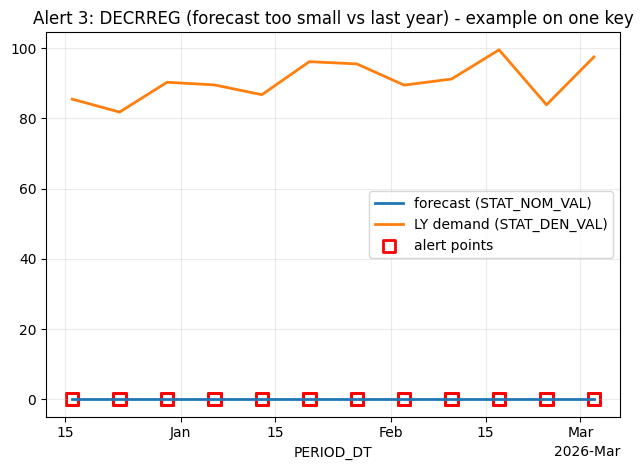

In [9]:
if not a23.empty:
    for typ, mode, title in [
        ("INCRREG", "high", "Alert 2: INCRREG (forecast too large vs last year)"),
        ("DECRREG", "low",  "Alert 3: DECRREG (forecast too small vs last year)"),
    ]:
        d = a23[a23["ALERT_TYPE"].eq(typ)].copy()
        if d.empty:
            continue

        thr = d["ALERT_THRESHOLD"].dropna().iloc[0] if "ALERT_THRESHOLD" in d.columns and d["ALERT_THRESHOLD"].notna().any() else 2
        plot_scatter_threshold(
            d,
            xcol="STAT_DEN_VAL",
            ycol="STAT_NOM_VAL",
            thr=float(thr),
            mode=mode,
            title=title,
            xlabel="STAT_DEN_VAL (demand a year ago)",
            ylabel="STAT_NOM_VAL (forecast)",
            max_points=1200
        )

        # adding context
        if "PERIOD_DT" in d.columns:
            ex = d.dropna(subset=["PERIOD_DT"]).iloc[0]
            key_cols = [c for c in d.columns if c.endswith("_ID") or "LVL_ID" in c]
            m = pd.Series(True, index=d.index)
            for c in key_cols:
                if c in d.columns and c in ex.index and pd.notna(ex[c]):
                    m &= (d[c] == ex[c])

            t = d.loc[m, ["PERIOD_DT","STAT_NOM_VAL","STAT_DEN_VAL","ALERT_STAT_VAL"]].copy()
            t["PERIOD_DT"] = pd.to_datetime(t["PERIOD_DT"], errors="coerce")
            t = t.dropna(subset=["PERIOD_DT"]).sort_values("PERIOD_DT")

            # alert_mask for boundary boxes
            if mode == "high":
                alert_mask = (t["STAT_NOM_VAL"] > float(thr) * t["STAT_DEN_VAL"])
            else:
                alert_mask = (t["STAT_NOM_VAL"] < t["STAT_DEN_VAL"] / float(thr))

            plot_ts_two(
                t,
                date_col="PERIOD_DT",
                y1_col="STAT_NOM_VAL",
                y2_col="STAT_DEN_VAL",
                alert_mask=alert_mask,
                title=f"{title} - example on one key",
                y1_label="forecast (STAT_NOM_VAL)",
                y2_label="LY demand (STAT_DEN_VAL)"
            )


Large forecasts got flagged by INCRREG, small forecasts - by DECRREG

## 4) Case: Alert 4/5 (HIGHREG / LOWREG)
The idea: the forecast deviates way too much from the demand over the last 3 months

In [10]:
a45 = out[out['ALERT_TYPE'].isin(['HIGHREG','LOWREG'])].copy()
a45.head()

,PRODUCT_LVL_ID7,LOCATION_LVL_ID5,CUSTOMER_LVL_ID3,DISTR_CHANNEL_LVL_ID1,PERIOD_DT,STAT_NOM_VAL,STAT_DEN_VAL,ALERT_TYPE,KPI_NM,INPUT_TABLE,...,STAT_DEN_NM,ALERT_THRESHOLD,STAT_NOM,STAT_DEN,ALERT_STAT_VAL,INPUT_COLUMN,INPUT_TABLE_COLUMN,PRODUCT_LVL_ID6,STAT_COUNT,SEGMENT_NAME
79,15,1,1,1,2025-12-16,2736.259934,79.91878,HIGHREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Average demand value within last 3 months,5.0,2736.259934,79.91878,34.238009,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
80,15,1,1,1,2025-12-23,3214.687028,79.91878,HIGHREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Average demand value within last 3 months,5.0,3214.687028,79.91878,40.224426,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
81,15,1,1,1,2025-12-30,2436.763867,79.91878,HIGHREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Average demand value within last 3 months,5.0,2436.763867,79.91878,30.490504,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
82,15,1,1,1,2026-01-06,2775.341235,79.91878,HIGHREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Average demand value within last 3 months,5.0,2775.341235,79.91878,34.727022,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
83,15,1,1,1,2026-01-13,3042.808745,79.91878,HIGHREG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Average demand value within last 3 months,5.0,3042.808745,79.91878,38.073764,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN


##### Display

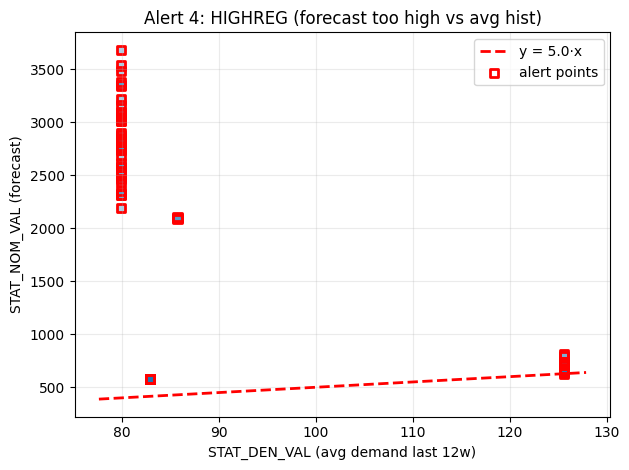

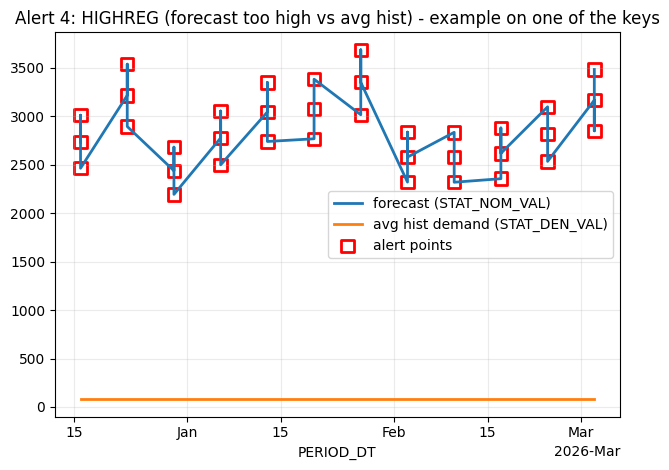

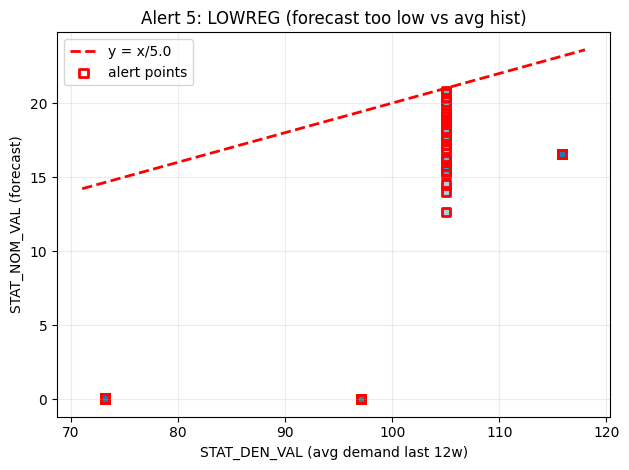

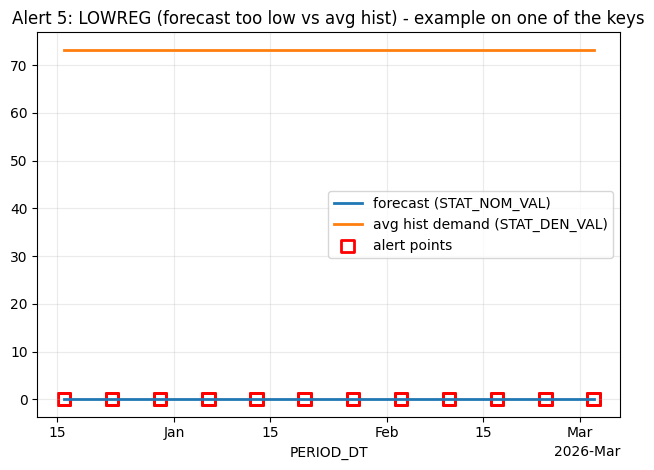

In [11]:
if not a45.empty:
    for typ, mode, title in [
        ("HIGHREG", "high", "Alert 4: HIGHREG (forecast too high vs avg hist)"),
        ("LOWREG",  "low",  "Alert 5: LOWREG (forecast too low vs avg hist)"),
    ]:
        d = a45[a45["ALERT_TYPE"].eq(typ)].copy()
        if d.empty:
            continue

        thr = d["ALERT_THRESHOLD"].dropna().iloc[0] if "ALERT_THRESHOLD" in d.columns and d["ALERT_THRESHOLD"].notna().any() else 5
        plot_scatter_threshold(
            d,
            xcol="STAT_DEN_VAL",
            ycol="STAT_NOM_VAL",
            thr=float(thr),
            mode=mode,
            title=title,
            xlabel="STAT_DEN_VAL (avg demand last 12w)",
            ylabel="STAT_NOM_VAL (forecast)",
            max_points=1200
        )

        if "PERIOD_DT" in d.columns:
            ex = d.dropna(subset=["PERIOD_DT"]).iloc[0]
            key_cols = [c for c in d.columns if c.endswith("_ID") or "LVL_ID" in c]
            m = pd.Series(True, index=d.index)
            for c in key_cols:
                if c in d.columns and c in ex.index and pd.notna(ex[c]):
                    m &= (d[c] == ex[c])

            t = d.loc[m, ["PERIOD_DT","STAT_NOM_VAL","STAT_DEN_VAL"]].copy()
            t["PERIOD_DT"] = pd.to_datetime(t["PERIOD_DT"], errors="coerce")
            t = t.dropna(subset=["PERIOD_DT"]).sort_values("PERIOD_DT")

            if mode == "high":
                alert_mask = (t["STAT_NOM_VAL"] > float(thr) * t["STAT_DEN_VAL"])
            else:
                alert_mask = (t["STAT_NOM_VAL"] < t["STAT_DEN_VAL"] / float(thr))

            plot_ts_two(
                t,
                date_col="PERIOD_DT",
                y1_col="STAT_NOM_VAL",
                y2_col="STAT_DEN_VAL",
                alert_mask=alert_mask,
                title=f"{title} - example on one of the keys",
                y1_label="forecast (STAT_NOM_VAL)",
                y2_label="avg hist demand (STAT_DEN_VAL)"
            )


Large forecasts got flagged by HIGHREG, small forecasts - by LOWREG

## 5) Case: Alert 6 (DEVWK)
The deviation of forecasts over the last week is too high (x2 or worse) compared to the deviation over the last 3 months

In [12]:
a6 = out[out['ALERT_TYPE'].eq('DEVWK')].copy()
a6.head()

,PRODUCT_LVL_ID7,LOCATION_LVL_ID5,CUSTOMER_LVL_ID3,DISTR_CHANNEL_LVL_ID1,PERIOD_DT,STAT_NOM_VAL,STAT_DEN_VAL,ALERT_TYPE,KPI_NM,INPUT_TABLE,...,STAT_DEN_NM,ALERT_THRESHOLD,STAT_NOM,STAT_DEN,ALERT_STAT_VAL,INPUT_COLUMN,INPUT_TABLE_COLUMN,PRODUCT_LVL_ID6,STAT_COUNT,SEGMENT_NAME
144,15,1,1,1,2025-12-16,2653.946954,26.269336,DEVWK,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Demand Deviation within last 3 months,2.0,NaN,NaN,101.028322,NaN,NaN,NaN,NaN,NaN
145,15,1,1,1,2025-12-23,3132.374047,26.269336,DEVWK,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Demand Deviation within last 3 months,2.0,NaN,NaN,119.240700,NaN,NaN,NaN,NaN,NaN
146,15,1,1,1,2025-12-30,2354.450887,26.269336,DEVWK,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Demand Deviation within last 3 months,2.0,NaN,NaN,89.627346,NaN,NaN,NaN,NaN,NaN
147,15,1,1,1,2026-01-06,2693.028255,26.269336,DEVWK,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Demand Deviation within last 3 months,2.0,NaN,NaN,102.516037,NaN,NaN,NaN,NaN,NaN
148,15,1,1,1,2026-01-13,2960.495765,26.269336,DEVWK,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Demand Deviation within last 3 months,2.0,NaN,NaN,112.697776,NaN,NaN,NaN,NaN,NaN


##### Display

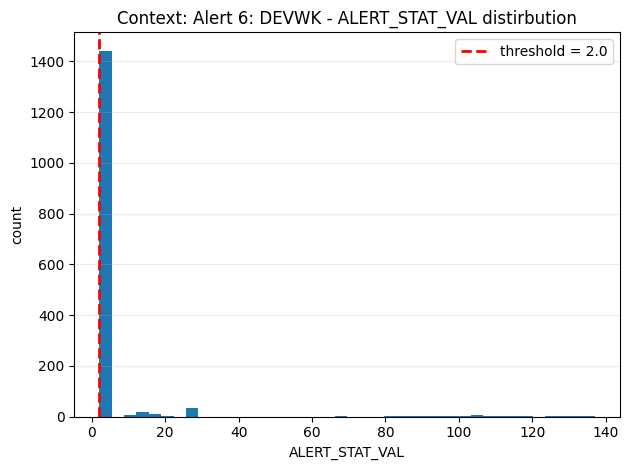

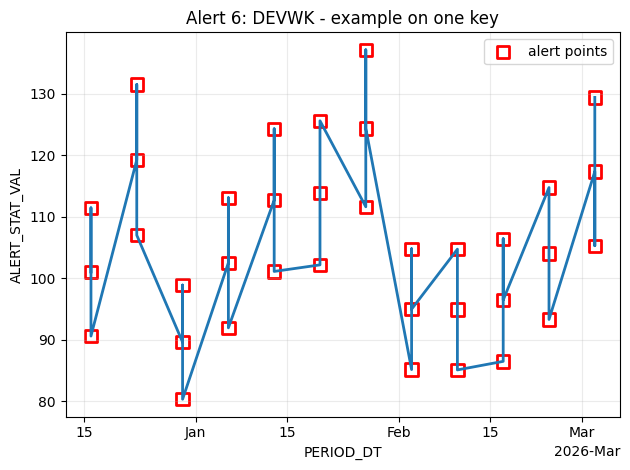

In [13]:
if not a6.empty:
    thr = a6["ALERT_THRESHOLD"].dropna().iloc[0] if "ALERT_THRESHOLD" in a6.columns and a6["ALERT_THRESHOLD"].notna().any() else 2

    s = pd.to_numeric(a6["ALERT_STAT_VAL"], errors="coerce").dropna().head(6000)
    plt.figure()
    plt.hist(s, bins=40)
    plt.axvline(float(thr), color="red", linestyle="--", linewidth=2, label=f"threshold = {thr}")
    plt.title("Context: Alert 6: DEVWK - ALERT_STAT_VAL distirbution")
    plt.xlabel("ALERT_STAT_VAL")
    plt.ylabel("count")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if "PERIOD_DT" in a6.columns:
        ex = a6.dropna(subset=["PERIOD_DT"]).iloc[0]
        key_cols = [c for c in a6.columns if c.endswith("_ID") or "LVL_ID" in c]
        m = pd.Series(True, index=a6.index)
        for c in key_cols:
            if c in a6.columns and c in ex.index and pd.notna(ex[c]):
                m &= (a6[c] == ex[c])

        t = a6.loc[m, ["PERIOD_DT","ALERT_STAT_VAL"]].copy()
        t["PERIOD_DT"] = pd.to_datetime(t["PERIOD_DT"], errors="coerce")
        t = t.dropna(subset=["PERIOD_DT"]).sort_values("PERIOD_DT")

        alert_mask = pd.to_numeric(t["ALERT_STAT_VAL"], errors="coerce") > float(thr)

        plot_ts_one(
            t,
            date_col="PERIOD_DT",
            val_col="ALERT_STAT_VAL",
            alert_mask=alert_mask,
            title="Alert 6: DEVWK - example on one key",
            ylabel="ALERT_STAT_VAL"
        )


A significant share of the records triggered this one - on our synthetic data, excess deviation is quite a problem

## 6) Case: Alert 7 (ZEROFLG)
The idea: there exists a non-zero forecast despite the absense of a forecast flag

In [14]:
a7 = out[out["ALERT_TYPE"].eq("ZEROFLG")].copy()
display(a7.head())

,PRODUCT_LVL_ID7,LOCATION_LVL_ID5,CUSTOMER_LVL_ID3,DISTR_CHANNEL_LVL_ID1,PERIOD_DT,STAT_NOM_VAL,STAT_DEN_VAL,ALERT_TYPE,KPI_NM,INPUT_TABLE,...,STAT_DEN_NM,ALERT_THRESHOLD,STAT_NOM,STAT_DEN,ALERT_STAT_VAL,INPUT_COLUMN,INPUT_TABLE_COLUMN,PRODUCT_LVL_ID6,STAT_COUNT,SEGMENT_NAME
398,21,3,2,2,2025-12-16,69.908065,1.0,ZEROFLG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,NaN,69.908065,1.0,69.908065,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
399,21,3,2,2,2025-12-23,93.126435,1.0,ZEROFLG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,NaN,93.126435,1.0,93.126435,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
400,21,3,2,2,2025-12-30,81.531043,1.0,ZEROFLG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,NaN,81.531043,1.0,81.531043,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
401,21,3,2,2,2026-01-06,76.160067,1.0,ZEROFLG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,NaN,76.160067,1.0,76.160067,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN
402,21,3,2,2,2026-01-13,77.820995,1.0,ZEROFLG,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,NaN,77.820995,1.0,77.820995,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,NaN,NaN


##### Preprocessing of output (Hide)

In [15]:
from utils_alerts import normalize_columns, add_level_columns, bucket_time

key_i=0
title_suffix = ""

a7 = out[out["ALERT_TYPE"].eq("ZEROFLG")].copy()
if a7.empty:
    print("no ZEROFLG in out")
    exit()

# fetch alert params
ap7 = alert_params_df[alert_params_df["ALERT_ID"].eq(7)].iloc[0]
al_p = int(ap7["AL_PRODUCT_LVL"])
al_l = int(ap7["AL_LOCATION_LVL"])
al_c = int(ap7["AL_CUSTOMER_LVL"])
al_d = int(ap7["AL_DISTR_CHANNEL_LVL"])
al_t = ap7["AL_TIME_LVL"] 

# take a key
key_i = int(key_i) if key_i is not None else 0
key_i = max(0, min(key_i, len(a7) - 1))
ex = a7.iloc[key_i]

tbl = ex.get("INPUT_TABLE")
col = ex.get("INPUT_COLUMN")

if not tbl:
    print("no INPUT_TABLE")
    exit()

df = tables.get(tbl)
if df is None or df.empty:
    print("no table", tbl)
    exit()

x = normalize_columns(df)

# dates and forecast
date_col = "PERIOD_DT" if "PERIOD_DT" in x.columns else _first_present(x, ["PERIOD_START_DT"])
if date_col is None:
    print("no date col in", tbl)
    exit()

if col is not None:
    val_col = str(col).upper()
else:
    val_col = _first_present(
        x, ["HYBRID_FORECAST_VALUE", "VF_FORECAST_VALUE", "FORECAST_VALUE"], default=None
    )
if val_col is None or val_col not in x.columns:
    print("no value col in ", tbl, ", requested:", col)
    exit()

x[date_col] = pd.to_datetime(x[date_col], errors="coerce")
x[val_col] = pd.to_numeric(x[val_col], errors="coerce")

# add hierarchy levels
x, p_col, l_col, c_col, d_col = add_level_columns(x, prod, loc, cust, dc, al_p, al_l, al_c, al_d)

# binned time + normalize to date
x[date_col] = bucket_time(x[date_col], al_t)
x[date_col] = pd.to_datetime(x[date_col], errors="coerce").dt.normalize()

# use data from out
key = x.copy()
for c in [p_col, l_col, c_col, d_col]:
    if c is not None and c in key.columns and c in ex.index and pd.notna(ex[c]):
        key = key[key[c] == ex[c]]

if key.empty:
    print("key series is empty")
    exit()

# peer: same LOC/CUST/DC, other products => median by period
peer = x.copy()
for c in [l_col, c_col, d_col]:
    if c is not None and c in peer.columns and c in ex.index and pd.notna(ex[c]):
        peer = peer[peer[c] == ex[c]]

# remove product (peer != key)
if p_col is not None and p_col in peer.columns and p_col in ex.index and pd.notna(ex[p_col]):
    peer = peer[peer[p_col] != ex[p_col]]

peer_med = (peer.groupby(date_col, dropna=False)[val_col]
                .median()
                .reset_index()
                .rename(columns={val_col: "PEER_MEDIAN"}))

# series + peer median
key_ts = (key[[date_col, val_col]]
            .dropna(subset=[date_col])
            .groupby(date_col, dropna=False)[val_col]
            .mean()
            .reset_index()
            .merge(peer_med, on=date_col, how="left")
            .sort_values(date_col))

# alert mask from out: PERIOD_DT now should be real
a7k = a7.copy()
a7k["PERIOD_DT"] = pd.to_datetime(a7k["PERIOD_DT"], errors="coerce").dt.normalize()

m = pd.Series(True, index=a7k.index)
for c in [p_col, l_col, c_col, d_col]:
    if c is not None and c in a7k.columns and c in ex.index and pd.notna(ex[c]):
        m &= (a7k[c] == ex[c])

alert_dates = set(a7k.loc[m, "PERIOD_DT"].dropna().unique())
key_ts["ALERT"] = key_ts[date_col].isin(alert_dates)


##### Display

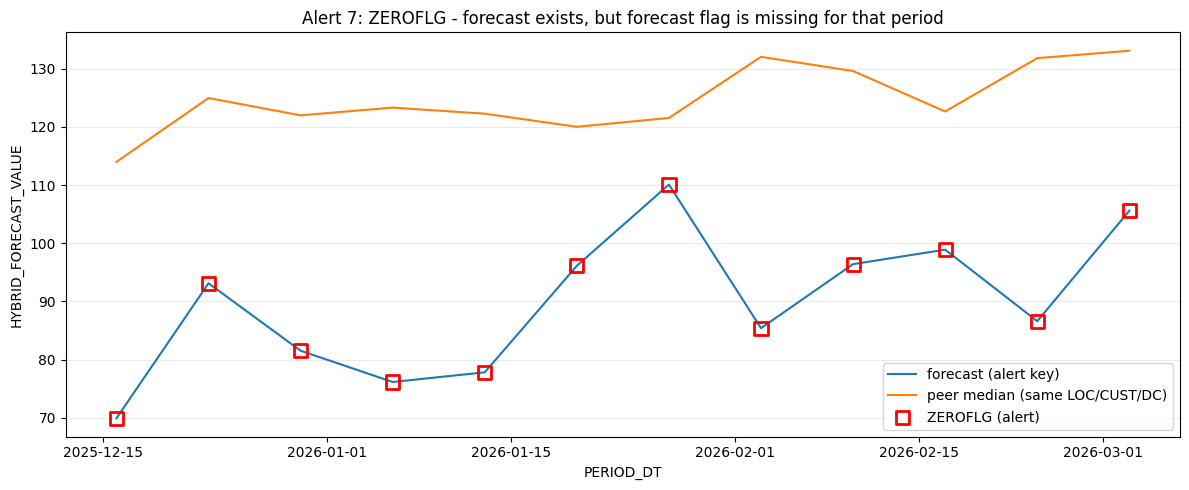

alerted periods for this key: 12


,PRODUCT_LVL_ID7,LOCATION_LVL_ID5,CUSTOMER_LVL_ID3,DISTR_CHANNEL_LVL_ID1,PRODUCT_LVL_ID6,cnt
0,21,3,2,2,NaN,36
1,271,5,1,1,NaN,36
2,182,4,3,2,NaN,36
3,187,3,1,2,NaN,36
4,194,4,4,1,NaN,36
5,206,2,3,1,NaN,36
6,218,6,4,2,NaN,36
7,221,5,3,1,NaN,36
8,228,4,3,1,NaN,36
9,240,4,1,1,NaN,36


In [16]:
# plot
plt.figure(figsize=(12, 5))
plt.plot(key_ts[date_col], key_ts[val_col], label="forecast (alert key)")
plt.plot(key_ts[date_col], key_ts["PEER_MEDIAN"], label="peer median (same LOC/CUST/DC)")

# red squares for alerts
ad = key_ts[key_ts["ALERT"]].copy()
if not ad.empty:
    plt.scatter(ad[date_col], ad[val_col], marker="s", facecolors="none",
                edgecolors="red", linewidths=2, s=90, zorder=5, label="ZEROFLG (alert)")
else:
    plt.text(0.01, 0.95, "no alert dates for this key", transform=plt.gca().transAxes)

ttl = "Alert 7: ZEROFLG - forecast exists, but forecast flag is missing for that period"
if title_suffix:
    ttl += " | " + str(title_suffix)
plt.title(ttl)
plt.xlabel("PERIOD_DT")
plt.ylabel(val_col)
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# small context: how many periods alerted for this key
print("alerted periods for this key:", len(alert_dates))

# top keys summary
key_cols = [c for c in a7.columns
            if c.startswith(("PRODUCT", "LOCATION", "CUSTOMER", "DISTR_CHANNEL"))
            and (c.endswith("_ID") or "LVL_ID" in c)]
if key_cols:
    top = (a7.groupby(key_cols, dropna=False)
                .size()
                .sort_values(ascending=False)
                .head(10)
                .reset_index(name="cnt"))
    display(top)

Forecasts which were calculated for data that is not supposed to be forecasted were flagged

## 7) Case: Alert 8 (SHRNEW)
The idea: the new product's forecast is too high/too low compared to average products

In [23]:
a8 = out[out['ALERT_TYPE'].eq('SHRNEW')].copy()
a8.head()

,PRODUCT_LVL_ID7,LOCATION_LVL_ID5,CUSTOMER_LVL_ID3,DISTR_CHANNEL_LVL_ID1,PERIOD_DT,STAT_NOM_VAL,STAT_DEN_VAL,ALERT_TYPE,KPI_NM,INPUT_TABLE,...,STAT_DEN_NM,ALERT_THRESHOLD,STAT_NOM,STAT_DEN,ALERT_STAT_VAL,INPUT_COLUMN,INPUT_TABLE_COLUMN,PRODUCT_LVL_ID6,STAT_COUNT,SEGMENT_NAME
1106,15,1,1,1,2025-12-16,2736.259934,83.959113,SHRNEW,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Average Demand for Regular Assortment,20.0,2736.259934,83.959113,32.590386,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,1.0,18.0,NaN
1107,15,1,1,1,2025-12-23,3214.687028,84.144638,SHRNEW,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Average Demand for Regular Assortment,20.0,3214.687028,84.144638,38.204300,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,1.0,18.0,NaN
1108,15,1,1,1,2025-12-30,2436.763867,89.892009,SHRNEW,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Average Demand for Regular Assortment,20.0,2436.763867,89.892009,27.107680,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,1.0,18.0,NaN
1109,15,1,1,1,2026-01-06,2775.341235,88.932548,SHRNEW,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Average Demand for Regular Assortment,20.0,2775.341235,88.932548,31.207261,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,1.0,18.0,NaN
1110,15,1,1,1,2026-01-13,3042.808745,89.376292,SHRNEW,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,Average Demand for Regular Assortment,20.0,3042.808745,89.376292,34.044920,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,1.0,18.0,NaN


##### Preprocessing of output (Hide)

In [26]:
from utils_alerts import parse_table_column_ref, col_for_hierarchy_level, agg_flags, shift_last_year

if a8.empty:
    print("no alert data")
    exit()

ex = a8.iloc[0]
ap8 = alert_params_df[alert_params_df["ALERT_ID"].eq(8)].iloc[0] if "alert_params_df" in globals() else None
al_p = int(ap8["AL_PRODUCT_LVL"]) if ap8 is not None and "AL_PRODUCT_LVL" in ap8 else None
al_l = int(ap8["AL_LOCATION_LVL"]) if ap8 is not None and "AL_LOCATION_LVL" in ap8 else None
al_c = int(ap8["AL_CUSTOMER_LVL"]) if ap8 is not None and "AL_CUSTOMER_LVL" in ap8 else None
al_d = int(ap8["AL_DISTR_CHANNEL_LVL"]) if ap8 is not None and "AL_DISTR_CHANNEL_LVL" in ap8 else None
al_t = ap8["AL_TIME_LVL"] if ap8 is not None and "AL_TIME_LVL" in ap8 else None
thr = float(ap8["ALERT_THRESHOLD"]) if ap8 is not None and "ALERT_THRESHOLD" in ap8 else float(ex.get("ALERT_THRESHOLD", 20.0))

# infer target_type from the parameters (needed to pick RESTORED_DEMAND_<target_type> and tgt_var_cfg)
tgt_type = None
tbl8, col8, tgt_type = ex.get("INPUT_TABLE"), ex.get("INPUT_COLUMN"), None

# forecast table for nominator
tbl = ex.get("INPUT_TABLE") or tbl8
col = ex.get("INPUT_COLUMN") or col8

df = tables.get(tbl) if tbl else None
if df is None or df.empty:
    print("no input table", tbl)
    exit()

x = normalize_columns(df)
date_col = "PERIOD_DT" if "PERIOD_DT" in x.columns else _first_present(x, ["PERIOD_START_DT"])
val_col = str(col).upper() if col else _first_present(
    x, ["HYBRID_FORECAST_VALUE", "VF_FORECAST_VALUE", "FORECAST_VALUE"], default=x.columns[-1]
)

x[date_col] = pd.to_datetime(x[date_col], errors="coerce")
x[val_col] = pd.to_numeric(x[val_col], errors="coerce")

# add levels on requested alert levels
if all(v is not None for v in [al_p, al_l, al_c, al_d]):
    x, p_col, l_col, c_col, d_col = add_level_columns(x, prod, loc, cust, dc, al_p, al_l, al_c, al_d)
else:
    p_col = _first_present(x, ["PRODUCT_ID"] + [c for c in x.columns if c.startswith("PRODUCT_LVL_ID")], default=None)
    l_col = _first_present(x, ["LOCATION_ID"] + [c for c in x.columns if c.startswith("LOCATION_LVL_ID")], default=None)
    c_col = _first_present(x, ["CUSTOMER_ID"] + [c for c in x.columns if c.startswith("CUSTOMER_LVL_ID")], default=None)
    d_col = _first_present(x, ["DISTR_CHANNEL_ID"] + [c for c in x.columns if c.startswith("DISTR_CHANNEL_LVL_ID")], default=None)

if al_t is not None and date_col is not None:
    x[date_col] = bucket_time(x[date_col], al_t)

# key forecast series (new product)
key = x.copy()
for c in [p_col, l_col, c_col, d_col]:
    if c is not None and c in key.columns and c in ex.index and pd.notna(ex[c]):
        key = key[key[c] == ex[c]]

key_stat = key.groupby(date_col, dropna=False)[val_col].mean().reset_index()
key_stat = key_stat.rename(columns={val_col: "NEW_FORECAST"})

# baseline regular demand: compute (for the parent product group + same LOC/CUST/DC), then shift by +1 year
rd = None
if tgt_type:
    for nm in [f"RESTORED_DEMAND_{tgt_type}", f"RESTORED_DEMAND_{str(tgt_type).upper()}"]:
        if nm in tables:
            rd = tables.get(nm)
            break
if rd is None:
    rd = tables.get("RESTORED_DEMAND")

if rd is None or rd.empty:
    print("no RESTORED_DEMAND for baseline")
    exit()

rd = normalize_columns(rd)
if "PERIOD_DT" not in rd.columns:
    if "PERIOD_START_DT" in rd.columns:
        rd["PERIOD_DT"] = rd["PERIOD_START_DT"]
    else:
        rd["PERIOD_DT"] = pd.NaT

rd["PERIOD_DT"] = pd.to_datetime(rd["PERIOD_DT"], errors="coerce")
if al_t is not None:
    rd["PERIOD_DT"] = bucket_time(rd["PERIOD_DT"], al_t)

# pick demand column for baseline
den_col = _first_present(rd, ["TGTSALES_QTY_R", "SALESTGT_QTY_R", "SALES_QTY", "SALES_QTY_R", "QTY", "VALUE"], default=None)
if den_col is None:
    print("no demand column found in RESTORED_DEMAND")
    exit()

# get product aggregation level from tgt_var_cfg (same as in alert8)
p_agg = None
if tgt_var_cfg and tgt_type and tgt_type in tgt_var_cfg:
    p_agg = int(tgt_var_cfg[tgt_type].get("AL_PRODUCT_AGG_LVL", al_p - 1))
if p_agg is None:
    p_agg = max(int(al_p or 2) - 1, 1)

p_agg_col = col_for_hierarchy_level("PRODUCT", p_agg)

# ensure levels and parent group are present
if all(v is not None for v in [al_p, al_l, al_c, al_d]):
    rd, rp_col, rl_col, rc_col, rd_col = add_level_columns(rd, prod, loc, cust, dc, al_p, al_l, al_c, al_d)
else:
    rp_col, rl_col, rc_col, rd_col = p_col, l_col, c_col, d_col

if p_agg_col not in rd.columns and "PRODUCT_ID" in rd.columns and prod is not None:
    prod_u = normalize_columns(prod)
    if "PRODUCT_ID" in prod_u.columns and p_agg_col in prod_u.columns:
        rd = rd.merge(prod_u[["PRODUCT_ID", p_agg_col]], on="PRODUCT_ID", how="left")

# classify regular assortment using FORECAST_FLAG
ff = tables.get("FORECAST_FLAG")
active_status = initial_global.get("IB_FF_ACTIVE_STATUS_LIST", ["active"]) if "initial_global" in globals() else ["active"]
max_np = int(initial_global.get("IB_MAX_NP_HISTORY", 30)) if "initial_global" in globals() else 30
hist_end = pd.to_datetime(initial_global.get("IB_HIST_END_DT")) if "initial_global" in globals() else None

ffa = agg_flags(ff, prod, loc, cust, dc, int(al_p or 1), int(al_l or 1), int(al_c or 1), int(al_d or 1), active_status)
if ffa.empty or hist_end is None:
    print("no FORECAST_FLAG or hist_end for a new/reg split")
    exit()

ffa["MIN_START_DT"] = pd.to_datetime(ffa["MIN_START_DT"], errors="coerce").dt.normalize()
ffa["NP_DAYS"] = (hist_end - ffa["MIN_START_DT"]).dt.days
reg_keys = ffa[ffa["NP_DAYS"] > max_np].copy()

# baseline only for the same LOC/CUST/DC and parent product group
reg_rd = rd.merge(reg_keys[[c for c in reg_keys.columns if c in [rp_col, rl_col, rc_col, rd_col]]].drop_duplicates(),
                    on=[c for c in [rp_col, rl_col, rc_col, rd_col] if c in rd.columns and c in reg_keys.columns],
                    how="inner")

if reg_rd.empty:
    print("no regular baseline data")
    exit()

g = [p_agg_col] + [c for c in [rl_col, rc_col, rd_col] if c is not None] + ["PERIOD_DT"]
base = (
    reg_rd.groupby(g, dropna=False)
        .agg(
            BASELINE=("{}".format(den_col), "mean"),
            STAT_COUNT=(rp_col, pd.Series.nunique),
        )
        .reset_index()
)
base = shift_last_year(base, al_t)

# filter baseline to the same LOC/CUST/DC as the example
for c in [rl_col, rc_col, rd_col]:
    if c is not None and c in base.columns and c in ex.index and pd.notna(ex[c]):
        base = base[base[c] == ex[c]]

# and to the same parent group as the example (if possible)
if p_agg_col in ex.index and pd.notna(ex[p_agg_col]):
    base = base[base[p_agg_col] == ex[p_agg_col]]

# merge forecast with baseline on PERIOD_DT
s = key_stat.merge(base[[c for c in base.columns if c in ["PERIOD_DT", "BASELINE"]]], left_on=date_col, right_on="PERIOD_DT", how="left")
s = s.rename(columns={"BASELINE": "REG_BASELINE"})
s["RATIO"] = s["NEW_FORECAST"] / s["REG_BASELINE"]

# build alert mask  
# normalize + bucket the timeline we plot
s[date_col] = pd.to_datetime(s[date_col], errors="coerce")
if al_t is not None:
    s[date_col] = bucket_time(s[date_col], al_t)
s[date_col] = pd.to_datetime(s[date_col], errors="coerce").dt.normalize()

# take alert rows for this key from out, and normalize+bucket them the same way
m = pd.Series(True, index=a8.index)
for c in [p_col, l_col, c_col, d_col]:
    if c is not None and c in a8.columns and c in ex.index and pd.notna(ex[c]):
        m &= (a8[c] == ex[c])

ad = a8.loc[m, ["PERIOD_DT"]].copy()
ad["PERIOD_DT"] = pd.to_datetime(ad["PERIOD_DT"], errors="coerce")
if al_t is not None:
    ad["PERIOD_DT"] = bucket_time(ad["PERIOD_DT"], al_t)
ad["PERIOD_DT"] = pd.to_datetime(ad["PERIOD_DT"], errors="coerce").dt.normalize()
ad = ad.dropna().drop_duplicates()

# left-join to mark alerts
s = s.merge(ad.assign(_ALERT=1), left_on=date_col, right_on="PERIOD_DT", how="left")
s["ALERT"] = s["_ALERT"].fillna(0).astype(int).eq(1)

##### Display

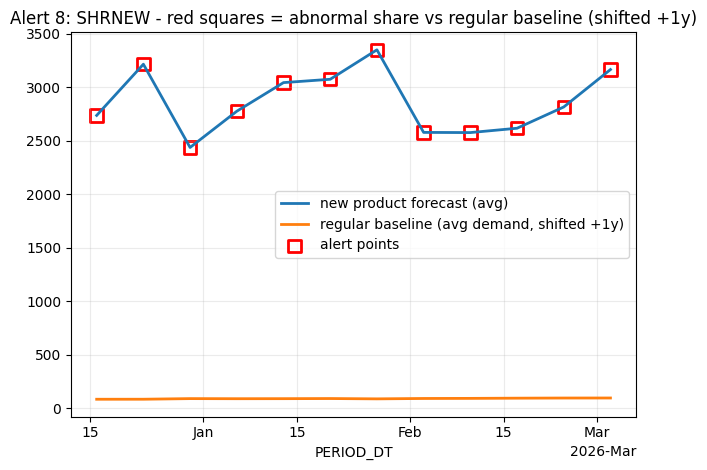

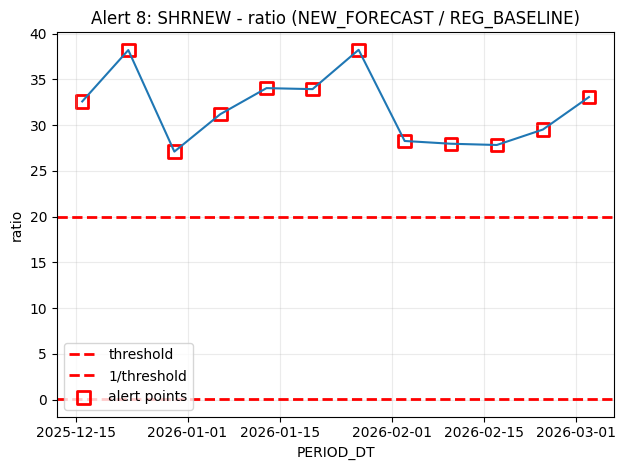

In [27]:
# time series with past forecast
plot_ts_two(
    s,
    date_col=date_col,
    y1_col="NEW_FORECAST",
    y2_col="REG_BASELINE",
    alert_mask=s["ALERT"],
    title="Alert 8: SHRNEW - red squares = abnormal share vs regular baseline (shifted +1y)",
    y1_label="new product forecast (avg)",
    y2_label="regular baseline (avg demand, shifted +1y)",
)

# time series (with threshold lines)
plt.figure()
plt.plot(pd.to_datetime(s[date_col], errors="coerce"), s["RATIO"])
plt.axhline(thr, color="red", linestyle="--", linewidth=2, label="threshold")
plt.axhline(1.0 / thr, color="red", linestyle="--", linewidth=2, label="1/threshold")
mm = s["ALERT"].fillna(False)
plt.scatter(pd.to_datetime(s.loc[mm, date_col], errors="coerce"), s.loc[mm, "RATIO"],
            marker="s", facecolors="none", edgecolors="red", linewidths=2, s=80, label="alert points")
plt.title("Alert 8: SHRNEW - ratio (NEW_FORECAST / REG_BASELINE)")
plt.xlabel(date_col)
plt.ylabel("ratio")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

All of the observed alerts were triggered above the threshold

## 8) Case: Alert 9 (LOWNEW)
The idea: the sum of the new product's forecasts is too low

In [ ]:
a9 = out[out["ALERT_TYPE"].eq("LOWNEW")].copy()
display(a9.head())

,PRODUCT_LVL_ID7,LOCATION_LVL_ID5,CUSTOMER_LVL_ID3,DISTR_CHANNEL_LVL_ID1,PERIOD_DT,STAT_NOM_VAL,STAT_DEN_VAL,ALERT_TYPE,KPI_NM,INPUT_TABLE,...,STAT_DEN_NM,ALERT_THRESHOLD,STAT_NOM,STAT_DEN,ALERT_STAT_VAL,INPUT_COLUMN,INPUT_TABLE_COLUMN,PRODUCT_LVL_ID6,STAT_COUNT,SEGMENT_NAME
1118,6,5,4,2,NaT,0.6,1.0,LOWNEW,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,1.0,0.6,1.0,0.6,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS.HYBRID_FORECAST_VALUE,NaN,12.0,NaN
2510,6,5,4,2,NaT,0.6,1.0,LOWNEW,sellout.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_SELLOUT,...,na,1.0,0.6,1.0,0.6,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_SELLOUT.HYBRID_FORECAS...,NaN,12.0,NaN
5011,6,5,4,2,NaT,0.6,1.0,LOWNEW,sellin.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_SELLIN,...,na,1.0,0.6,1.0,0.6,HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_SELLIN.HYBRID_FORECAST...,NaN,12.0,NaN


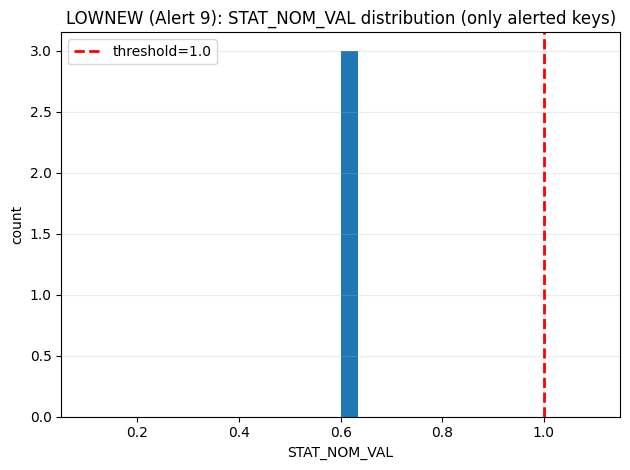

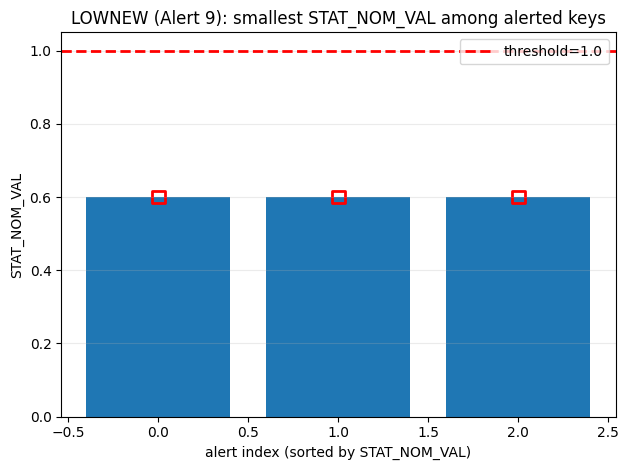

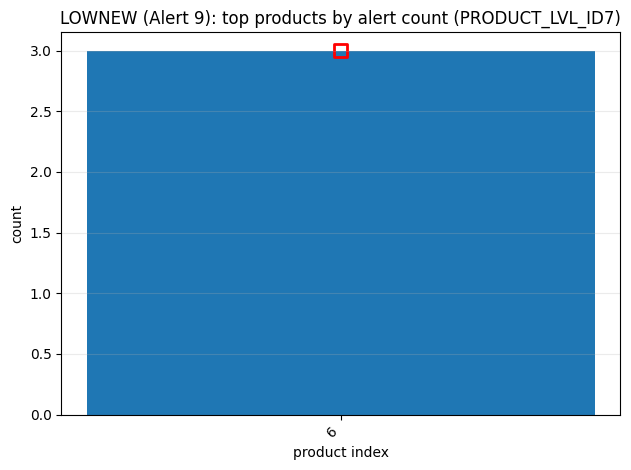

In [ ]:
import re

if a9.empty:
    print("LOWNEW is empty")
    exit()

# threshold
thr = float(a9["ALERT_THRESHOLD"].dropna().iloc[0]) if "ALERT_THRESHOLD" in a9.columns and a9["ALERT_THRESHOLD"].notna().any() else 1.0

# ensure numeric dtype
a9["STAT_NOM_VAL"] = pd.to_numeric(a9.get("STAT_NOM_VAL"), errors="coerce")
if "STAT_COUNT" in a9.columns:
    a9["STAT_COUNT"] = pd.to_numeric(a9["STAT_COUNT"], errors="coerce")

# id columns that actually exist in alert9 output (lvl columns)
id_cols = [c for c in a9.columns if re.match(r"^(PRODUCT|LOCATION|CUSTOMER|DISTR_CHANNEL)", str(c), flags=re.I)]
id_cols = [c for c in id_cols if ("LVL" in str(c).upper()) or str(c).upper().endswith("_ID")]

# build a readable key label
def _key_label(r):
    parts = []
    for c in id_cols:
        v = r.get(c)
        if pd.notna(v):
            parts.append(f"{c}={v}")
    return " | ".join(parts) if parts else "<no ids>"

d = a9.dropna(subset=["STAT_NOM_VAL"]).copy()
d["KEY"] = d.apply(_key_label, axis=1)
d = d.sort_values("STAT_NOM_VAL")

# histogram of alert values 
plt.figure()
plt.hist(d["STAT_NOM_VAL"].to_numpy(), bins=30)
plt.axvline(thr, color="red", linestyle="--", linewidth=2, label=f"threshold={thr}")
plt.title("LOWNEW (Alert 9): STAT_NOM_VAL distribution (only alerted keys)")
plt.xlabel("STAT_NOM_VAL")
plt.ylabel("count")
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# bottom-N barchart
bot = d.head(30).copy()
plt.figure()
plt.bar(range(len(bot)), bot["STAT_NOM_VAL"].to_numpy())
plt.axhline(thr, color="red", linestyle="--", linewidth=2, label=f"threshold={thr}")
bad = bot["STAT_NOM_VAL"] < thr
plt.scatter(np.where(bad)[0], bot.loc[bad, "STAT_NOM_VAL"],
            marker="s", facecolors="none", edgecolors="red", linewidths=2, s=80)
plt.title("LOWNEW (Alert 9): smallest STAT_NOM_VAL among alerted keys")
plt.xlabel("alert index (sorted by STAT_NOM_VAL)")
plt.ylabel("STAT_NOM_VAL")
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# which products trigger LOWNEW most often (using whatever PRODUCT_* column exists)
pcols = [c for c in id_cols if str(c).upper().startswith("PRODUCT")]
if pcols:
    pcol = pcols[0]
    top = d[pcol].value_counts().head(15)
    plt.figure()
    plt.bar(range(len(top)), top.values)
    plt.scatter(range(len(top)), top.values, marker="s", facecolors="none", edgecolors="red", linewidths=2, s=80)
    plt.title(f"LOWNEW (Alert 9): top products by alert count ({pcol})")
    plt.xlabel("product index")
    plt.ylabel("count")
    plt.xticks(range(len(top)), top.index, rotation=45, ha="right")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("No PRODUCT* id column found in alert9 output; can't compute per-product counts.")


Only one product triggered this specific alert among three different forecast types - sellout, sellin, pos

## 9) Case: Alert 10 (NONSEAS)
The idea: for a long TS (seasonal data), a nonseasonal forecasting method is used.

In [ ]:
a10 = out[out['ALERT_TYPE'].eq('NONSEAS')].copy()
a10.head()

,PRODUCT_LVL_ID7,LOCATION_LVL_ID5,CUSTOMER_LVL_ID3,DISTR_CHANNEL_LVL_ID1,PERIOD_DT,STAT_NOM_VAL,STAT_DEN_VAL,ALERT_TYPE,KPI_NM,INPUT_TABLE,...,STAT_DEN_NM,ALERT_THRESHOLD,STAT_NOM,STAT_DEN,ALERT_STAT_VAL,INPUT_COLUMN,INPUT_TABLE_COLUMN,PRODUCT_LVL_ID6,STAT_COUNT,SEGMENT_NAME
1119,334,4,1,1,NaT,NaN,1.0,NONSEAS,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONSEAS
1120,122,5,4,1,NaT,NaN,1.0,NONSEAS,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONSEAS
1121,112,3,3,2,NaT,NaN,1.0,NONSEAS,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONSEAS
1122,288,6,4,1,NaT,NaN,1.0,NONSEAS,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONSEAS
1123,399,5,2,1,NaT,NaN,1.0,NONSEAS,pos.HYBRID_FORECAST_VALUE,ACC_AGG_HYBRID_FORECAST_POS,...,na,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONSEAS


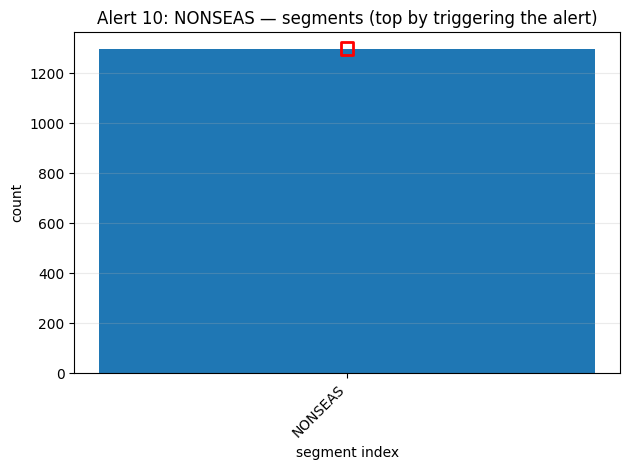

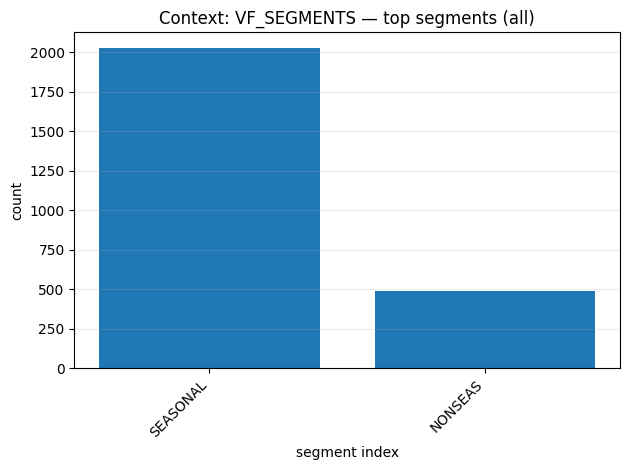

In [ ]:
if not a10.empty:
    # how many triggers of the alert happened in each segment?
    seg_col = _first_present(a10, ["SEGMENT_NAME", "VF_SEGMENT_NAME", "SEGMENT"])
    if seg_col is not None:
        vc = a10[seg_col].value_counts().head(15)
        plt.figure()
        plt.bar(range(len(vc)), vc.values)
        plt.scatter(range(len(vc)), vc.values, marker="s", facecolors="none", edgecolors="red", linewidths=2, s=80)
        plt.title("Alert 10: NONSEAS — segments (top by triggering the alert)")
        plt.xlabel("segment index")
        plt.ylabel("count")
        plt.xticks(range(len(vc)), vc.index, rotation=45, ha="right")
        plt.grid(True, axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

    # context: what's the general distibution of the segments?
    vf = tables.get("VF_SEGMENTS")
    if vf is not None and not vf.empty:
        vf2 = vf.copy()
        seg2 = _first_present(vf2, ["SEGMENT_NAME","VF_SEGMENT_NAME","SEGMENT"])
        if seg2 is not None:
            all_vc = vf2[seg2].value_counts().head(15)
            plt.figure()
            plt.bar(range(len(all_vc)), all_vc.values)
            plt.title("Context: VF_SEGMENTS — top segments (all)")
            plt.xlabel("segment index")
            plt.ylabel("count")
            plt.xticks(range(len(all_vc)), all_vc.index, rotation=45, ha="right")
            plt.grid(True, axis="y", alpha=0.25)
            plt.tight_layout()
            plt.show()


There were more triggers of this alert on seasonal data than there were actual nonseasonal records in the dataset